# 09 — The Decision Framework (Act IV: the contribution)

> **The resolution of the story.** Accuracy ties (Act I); cost and latency
> separate the field (Act II); the best family is conditional and partly
> predictable (Act III). Here we synthesize all axes into the two artifacts that
> do **not** exist in the literature for the 2024–2025 model set:
>
> 1. a **multi-criteria decision matrix** (model x criteria, scored), and
> 2. a **practitioner flowchart** (answer a few questions -> defensible shortlist).
>
> We open with the *rigorous* statement of the tie (Bayesian + variance), because
> the whole framework rests on "accuracy doesn't decide it."

In [1]:
import sys; sys.path.insert(0, '..')
import os, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src.data.registry import load_dataset, get_all_dataset_names
from src.models.factory import get_model_family
from src.evaluation.enrichments import (
    PRIMARY, FAMILY_SHORT, bayesian_signed_rank, bayesian_pairwise_table,
    normalized_regret, family_variance_decomposition, build_meta_features,
    winning_family_table, winner_decision_tree, fold_robustness,
)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})
os.makedirs('../results/figures', exist_ok=True)
FAMC = {'GBDT': '#2196F3', 'DL': '#FF9800', 'FM': '#4CAF50'}

test = pd.read_csv('../results/aggregated/test_results.csv')
FAM = {m: get_model_family(m) for m in test.model.unique()}
meta = build_meta_features(get_all_dataset_names(), load_dataset,
                           '../configs/datasets.yaml', data_dir='../data/raw')
print('loaded', test.shape, '| datasets:', meta.shape[0])

loaded (197, 16) | datasets: 18


In [2]:
fold = pd.read_csv('../results/aggregated/fold_results.csv',
                   usecols=['model','dataset','task_type','fold','roc_auc','log_loss','rmse'])
# latency (measured separately on adult)
lat = pd.read_csv('../results/latency/latency_adult.csv').set_index('model')['us_per_row']

## 1. The tie, stated rigorously (Act I)

Two ways to show the top cluster is indistinguishable, both stronger than a bare
average: **(a) Bayesian signed-rank vs the rank-leader TabPFN** with a region of
practical equivalence (ROPE = 0.01 AUC), and **(b) variance decomposition** —
how much of the rank spread is *between* families vs *within* them.

In [3]:
b = test[test.task_type=='binary']
piv = b.pivot(index='dataset', columns='model', values='roc_auc').dropna(axis=1)
bt = bayesian_pairwise_table(piv, higher_is_better=True, rope=0.01, ref='tabpfn')
bt = bt.sort_values('P(better)', ascending=False)
print('Bayesian signed-rank vs TabPFN (binary, ROPE=+/-0.01 AUC):')
display(bt.round(2))

vd = family_variance_decomposition(piv.rank(axis=1, ascending=False), FAM)
print(f"\nVariance decomposition of binary ranks:")
print(f"  eta^2 (between-family share) = {vd['eta_squared']:.2f}")
print(f"  -> {(1-vd['eta_squared'])*100:.0f}% of rank variance is WITHIN families")
print(f"  family mean ranks: {vd['family_mean_rank']}")
print('\nInterpretation: most competitors are within the ROPE of TabPFN '
      '(practically equivalent), and within-family spread dwarfs between-family '
      'spread -> "GBDT vs DL" is a weak abstraction; the model matters more than its family.')

Bayesian signed-rank vs TabPFN (binary, ROPE=+/-0.01 AUC):


,model,vs,P(worse),P(equiv),P(better)
0,catboost,tabpfn,0.05,0.78,0.17
2,lightgbm,tabpfn,0.15,0.82,0.03
1,ft_transformer,tabpfn,0.44,0.54,0.02
3,mlp,tabpfn,0.49,0.51,0.00
4,realmlp,tabpfn,0.33,0.67,0.00
5,saint,tabpfn,0.44,0.56,0.00
6,stab,tabpfn,0.55,0.45,0.00
7,tabm,tabpfn,0.36,0.64,0.00
8,tabnet,tabpfn,0.82,0.18,0.00
9,xgboost,tabpfn,0.06,0.94,0.00



Variance decomposition of binary ranks:
  eta^2 (between-family share) = 0.20
  -> 80% of rank variance is WITHIN families
  family mean ranks: {'deep_learning': 7.043, 'foundation_model': 3.2, 'gbdt': 4.5}

Interpretation: most competitors are within the ROPE of TabPFN (practically equivalent), and within-family spread dwarfs between-family spread -> "GBDT vs DL" is a weak abstraction; the model matters more than its family.


## 2. The decision matrix

Each model is scored ★/★★/★★★ on the criteria the finished benchmark supports.
Scores are **computed from the data**, not asserted: performance from normalized
regret, cost from training time, latency from the measured µs/row, robustness
from worst-case fold rank. Interpretability is a documented qualitative rule
(intrinsic for GBDTs, partial for attention, opaque for MLP/FM).

,family,C1 Perf,C6 TrainCost,C8 Tuning,C7 Latency,C10 Robust,C9 Interp
model,,,,,,,
tabpfn,FM,***,***,***,*,***,*
catboost,GBDT,***,**,**,***,***,***
xgboost,GBDT,***,***,***,***,**,***
lightgbm,GBDT,**,***,***,**,**,***
realmlp,DL,**,**,**,***,**,*
tabm,DL,**,**,**,**,**,*
ft_transformer,DL,**,*,*,*,**,**
saint,DL,*,*,*,*,**,**
stab,DL,*,*,*,*,**,*


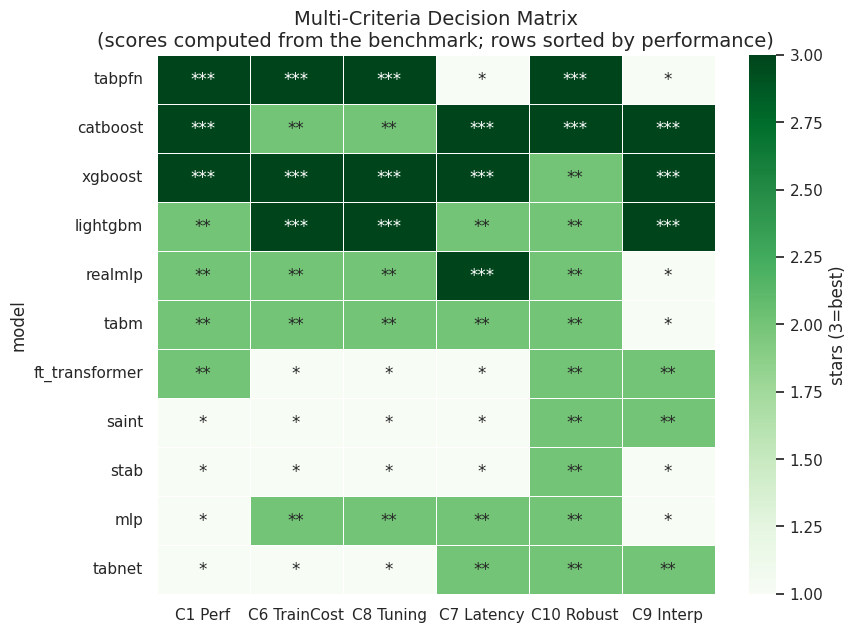

In [4]:
import numpy as np
models = sorted(test.model.unique())
# --- quantitative ingredients ---
regret_bin = normalized_regret(piv, True)
reg_df = test[test.task_type=='regression'].pivot(index='dataset', columns='model', values='rmse').dropna(axis=1)
regret_reg = normalized_regret(reg_df, False)
perf = pd.concat([regret_bin, regret_reg], axis=1).mean(axis=1)  # lower=better
train = test.groupby('model')['train_time_s'].median()
tune = test.groupby('model')['tuning_time_s'].median()
rob = fold_robustness(fold)['worst_rank']

def stars(series, lower_better, model):
    s = series.rank(ascending=lower_better)  # rank 1 = best
    q = s[model] / len(series)
    return '***' if q <= 1/3 else '**' if q <= 2/3 else '*'

# interpretability: qualitative by family
INTERP = {'gbdt': '***', 'deep_learning': '*', 'foundation_model': '*'}
INTERP_ATTN = {'ft_transformer':'**','tabnet':'**','saint':'**'}  # attention: partial

rows = []
for m in models:
    fam = FAM[m]
    rows.append({
        'model': m, 'family': FAMILY_SHORT[fam],
        'C1 Perf': stars(perf, True, m),
        'C6 TrainCost': stars(train, True, m),
        'C8 Tuning': '***' if m=='tabpfn' else stars(tune.reindex(models).fillna(tune.max()), True, m),
        'C7 Latency': stars(lat.reindex(models).fillna(lat.max()), True, m),
        'C10 Robust': stars(rob, True, m),
        'C9 Interp': INTERP_ATTN.get(m, INTERP[fam]),
    })
matrix = pd.DataFrame(rows).set_index('model')
order = perf.sort_values().index
matrix = matrix.loc[order]
display(matrix)

# heatmap view (stars -> 1..3)
num = matrix.drop(columns='family').applymap(lambda s: len(s))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(num, annot=matrix.drop(columns='family').values, fmt='', cmap='Greens',
            vmin=1, vmax=3, linewidths=.5, cbar_kws={'label':'stars (3=best)'}, ax=ax)
ax.set_title('Multi-Criteria Decision Matrix\n(scores computed from the benchmark; rows sorted by performance)')
plt.savefig('../results/figures/decision_matrix.png'); plt.show()

**Reading.** No model is ★★★ everywhere — that is the point. TabPFN dominates
performance/tuning/robustness but is ★ on latency; GBDTs are the all-rounders
(strong on cost, latency, interpretability, never catastrophic); the heavy DL
models rarely justify their column. The matrix *is* the practitioner's reference
card.

## 3. The practitioner flowchart

Derived from the meta-feature tree (notebook 08) plus the cost/latency findings.
Answer three questions about your problem and get a defensible shortlist.

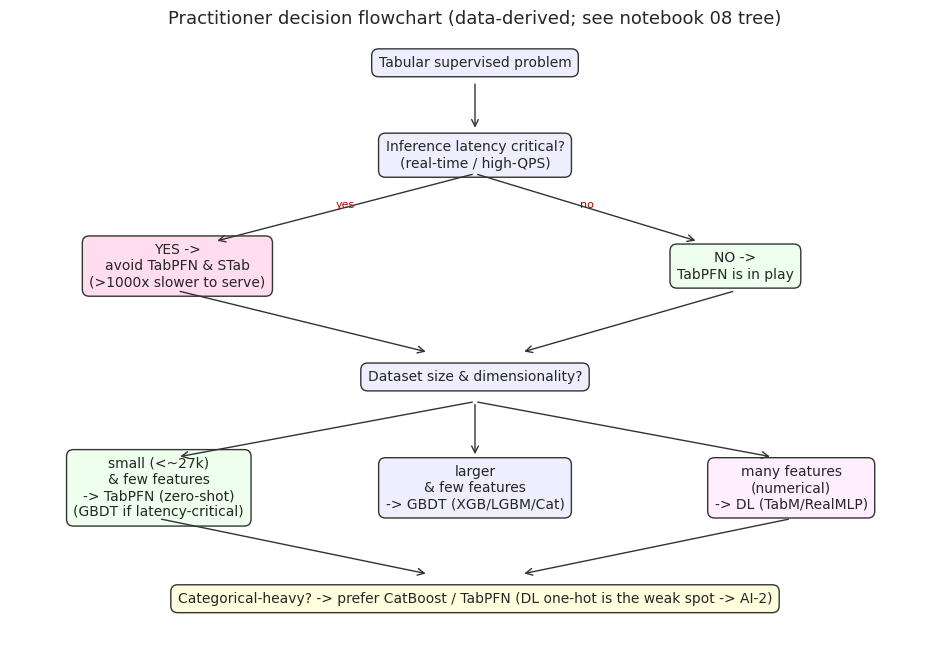

In [5]:
fig, ax = plt.subplots(figsize=(12, 8)); ax.axis('off')
def box(x, y, t, c='#eef'):
    ax.annotate(t, (x,y), ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc=c, ec='#333'))
def arrow(x1,y1,x2,y2,lbl=''):
    ax.annotate('', (x2,y2), (x1,y1), arrowprops=dict(arrowstyle='->', color='#333'))
    if lbl: ax.text((x1+x2)/2, (y1+y2)/2, lbl, fontsize=8, color='#a00', ha='center')

box(0.5,0.95,'Tabular supervised problem')
box(0.5,0.80,'Inference latency critical?\n(real-time / high-QPS)')
arrow(0.5,0.92,0.5,0.84)
box(0.18,0.62,'YES ->\navoid TabPFN & STab\n(>1000x slower to serve)', '#fde')
box(0.78,0.62,'NO ->\nTabPFN is in play', '#efe')
arrow(0.5,0.77,0.22,0.66,'yes'); arrow(0.5,0.77,0.74,0.66,'no')
box(0.5,0.44,'Dataset size & dimensionality?')
arrow(0.18,0.58,0.45,0.48); arrow(0.78,0.58,0.55,0.48)
box(0.16,0.26,'small (<~27k)\n& few features\n-> TabPFN (zero-shot)\n(GBDT if latency-critical)','#efe')
box(0.5,0.26,'larger\n& few features\n-> GBDT (XGB/LGBM/Cat)','#eef')
box(0.84,0.26,'many features\n(numerical)\n-> DL (TabM/RealMLP)','#fef')
arrow(0.5,0.40,0.18,0.31); arrow(0.5,0.40,0.5,0.31); arrow(0.5,0.40,0.82,0.31)
box(0.5,0.08,'Categorical-heavy? -> prefer CatBoost / TabPFN (DL one-hot is the weak spot -> AI-2)','#ffd')
arrow(0.16,0.21,0.45,0.12); arrow(0.84,0.21,0.55,0.12)
ax.set_title('Practitioner decision flowchart (data-derived; see notebook 08 tree)', fontsize=13)
plt.savefig('../results/figures/decision_flowchart.png'); plt.show()

## 4. Family narratives & where the next contribution lives

- **GBDTs** — the rational default: top-cluster accuracy, cheapest to train,
  fast to serve, interpretable, never catastrophic. Hard to beat *unless* a
  specific axis (zero-shot, multiclass, high-dim) matters.
- **Foundation model (TabPFN)** — best average rank and the highest floor, with
  zero tuning, for small/medium low-dimensional data — but inverts to the most
  expensive at inference. Batch/low-QPS only.
- **Deep learning** — earns its cost only on high-dimensional numerical and
  multiclass problems (TabM/RealMLP/STab); the attention models are mostly
  dominated and break on categorical-heavy data.

**Where Individual Development 2 lives:** the clearest, most actionable gap is
**DL's categorical-encoding bottleneck** (one-hot explosion -> attention OOM /
degradation on `amazon_employee`). A learned-embedding or target-encoding
pipeline that closes the DL–GBDT gap on categorical-heavy data is a concrete,
validatable contribution seeded directly by this benchmark.